# Model Development & Tracking
## Stage 3 · baseline + advanced models, MLflow tracking & registry

- Each stage lists its **sub-tasks as a checklist**
- Complete every `# TODO`; implement the training logic in `src/train.py` (metrics helper provided in `src/evaluate.py`) and call it here.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`
- *Provided to extend:* `src/train.py`. 
- *You create:* the cells below.

## Stage 3.1 — Baseline Model (Logistic Regression)

- **3.1.1 — Logistic Regression baseline trained (Pipeline, imbalance handled) [3]** — `LogisticRegression(class_weight='balanced')` as a full Pipeline (preprocess + classify), fit on train.
- **3.1.2 — Baseline evaluated on validation [2]** — report imbalance-aware validation metrics (ROC-AUC / PR-AUC / recall).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, joblib, mlflow, numpy as np, pandas as pd, matplotlib.pyplot as plt
import config as cfg, src.data_prep as dp
from src.evaluate import compute_metrics, confusion
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Stage 2 gives us everything: frame -> feature lists -> stratified splits
fe = dp.get_model_frame()
numeric, categorical = dp.get_feature_lists(fe)
X_train, X_val, X_test, y_train, y_val, y_test = dp.get_splits(fe)

print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"train positive rate: {y_train.mean():.2%}")

# TODO 3.1.1: build & fit the LogReg baseline Pipeline (class_weight='balanced').

# 3.1.1 - preprocessor + classifier as ONE pipeline
logreg = Pipeline([
    ("prep", dp.build_preprocessor(numeric, categorical)),
    ("clf", LogisticRegression(max_iter=1000,
                               class_weight="balanced",
                               random_state=cfg.RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

# TODO 3.1.2: evaluate it on the validation split and print the metrics.
# evaluate on validation
val_prob_lr = logreg.predict_proba(X_val)[:, 1]
lr_metrics = compute_metrics(y_val, val_prob_lr)
print("\nLogistic Regression - validation:")
for k, v in lr_metrics.items():
    print(f"  {k:10s} {v}")


train (44782, 39) | val (11196, 39) | test (13995, 39)
train positive rate: 8.97%

Logistic Regression - validation:
  roc_auc    0.6543
  pr_auc     0.1711
  f1         0.2263
  recall     0.5408
  precision  0.143
  accuracy   0.6683


## Stage 3.2 — Advanced Model (XGBoost)

- **3.2.1 — XGBoost trained (Pipeline, `scale_pos_weight` imbalance handled) [5]** — XGBoost with `scale_pos_weight = neg/pos` as a full Pipeline, fit on train.
- **3.2.2 — Advanced model evaluated on validation [3]** — report the same validation metrics for comparison with the baseline.

In [3]:
from xgboost import XGBClassifier

# TODO 3.2.1: build & fit the XGBoost Pipeline (scale_pos_weight = neg/pos).
# imbalance ratio from TRAIN ONLY (val/test must stay unseen)
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = neg / pos
print(f"neg={neg:,} pos={pos:,} -> scale_pos_weight={scale_pos_weight:.2f}")

xgb = Pipeline([
    ("prep", dp.build_preprocessor(numeric, categorical)),  # fresh instance!
    ("clf", XGBClassifier(scale_pos_weight=scale_pos_weight, **cfg.XGB_PARAMS)),
])
xgb.fit(X_train, y_train)

# TODO 3.2.2: evaluate it on the validation split and print the metrics.
# same metrics for a like-for-like comparison
val_prob_xgb = xgb.predict_proba(X_val)[:, 1]
xgb_metrics = compute_metrics(y_val, val_prob_xgb)
print("\nXGBoost - validation:")
for k, v in xgb_metrics.items():
    print(f"  {k:10s} {v}")

neg=40,764 pos=4,018 -> scale_pos_weight=10.15

XGBoost - validation:
  roc_auc    0.6542
  pr_auc     0.18
  f1         0.2388
  recall     0.4711
  precision  0.16
  accuracy   0.7307


## Stage 3.3 — Model Evaluation

- **3.3.1 — Imbalance-aware metrics + model selection [3]** — ROC-AUC, PR-AUC, recall, precision, F1 for both models in a comparison table; select on ROC-AUC.
- **3.3.2 — Plots + interpretation (why accuracy misleads) [2]** — ROC + confusion plots; explain why accuracy is misleading at ~9% prevalence.

,roc_auc,pr_auc,recall,precision,f1,accuracy
logistic_regression,0.6543,0.1711,0.5408,0.143,0.2263,0.6683
xgboost,0.6542,0.1800,0.4711,0.160,0.2388,0.7307


Selected: logistic_regression (val ROC-AUC 0.6543)


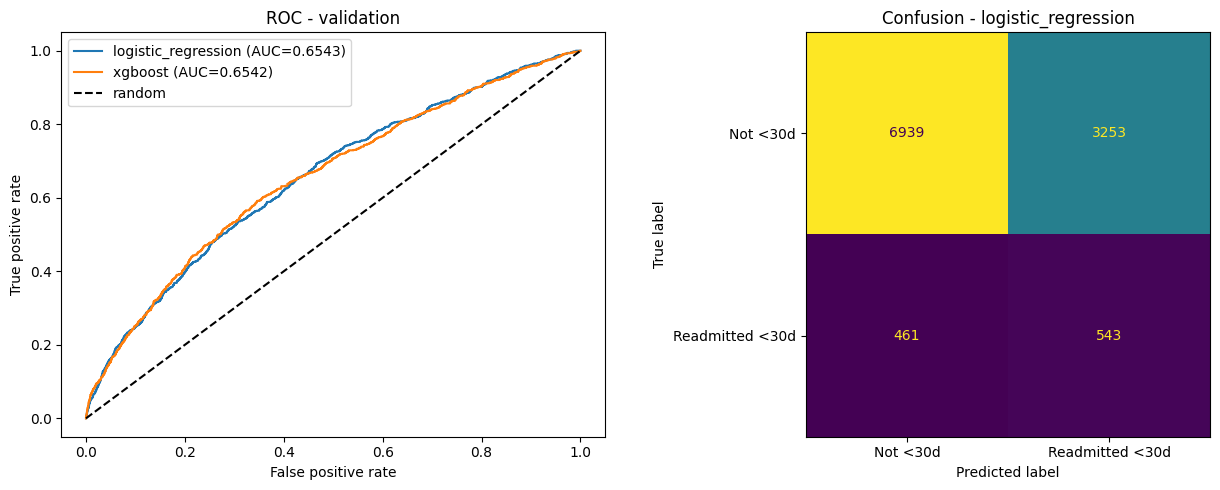


Always-predict-0 accuracy: 91.03%
logistic_regression accuracy:      66.83%
PR-AUC random baseline:    0.0897 (= prevalence)
logistic_regression PR-AUC:        0.1711


In [4]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

# 3.3.1 - build the metric comparison table and select the best model on ROC-AUC
comparison = pd.DataFrame({
    "logistic_regression": lr_metrics,
    "xgboost": xgb_metrics,
}).T[["roc_auc", "pr_auc", "recall", "precision", "f1", "accuracy"]]
display(comparison)

best_name = comparison["roc_auc"].idxmax()
best_model = {"logistic_regression": logreg, "xgboost": xgb}[best_name]
best_prob = {"logistic_regression": val_prob_lr, "xgboost": val_prob_xgb}[best_name]
print(f"Selected: {best_name} (val ROC-AUC {comparison.loc[best_name, 'roc_auc']})")

# 3.3.2: plot ROC + confusion for the best model; add a written interpretation.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, prob in [("logistic_regression", val_prob_lr), ("xgboost", val_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={comparison.loc[name, 'roc_auc']})")
axes[0].plot([0, 1], [0, 1], "k--", label="random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC - validation")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_val, (best_prob >= 0.5).astype(int),
    display_labels=["Not <30d", "Readmitted <30d"], ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion - {best_name}")
plt.tight_layout()
plt.show()

# the "accuracy is misleading" proof
majority_acc = 1 - y_val.mean()
print(f"\nAlways-predict-0 accuracy: {majority_acc:.2%}")
print(f"{best_name} accuracy:      {comparison.loc[best_name, 'accuracy']:.2%}")
print(f"PR-AUC random baseline:    {y_val.mean():.4f} (= prevalence)")
print(f"{best_name} PR-AUC:        {comparison.loc[best_name,'pr_auc']}")

## Stage 3.4 — MLflow Experiment Tracking

- **3.4.1 — Both runs logged with params + metrics + model [4]** — set tracking URI + experiment; for each model log params, metrics and the model artefact.
- **3.4.2 — Runs compared (search_runs table) [3]** — compare the runs with `mlflow.search_runs(...)` and state the selection criterion.

In [7]:
# 3.4.1: log both runs (params + metrics + model) to an MLflow experiment.
mlflow.set_tracking_uri(cfg.MLFLOW_TRACKING_URI)    # sqlite:///mlflow.db
mlflow.set_experiment(cfg.MLFLOW_EXPERIMENT)

runs = {}
for name, model, metrics in [
    ("logistic_regression", logreg, lr_metrics),
    ("xgboost",             xgb,    xgb_metrics),
]:
    with mlflow.start_run(run_name=name) as run:
        mlflow.log_param("model_type", name)
        mlflow.log_param("n_train", len(X_train))
        mlflow.log_param("n_features_raw", X_train.shape[1])
        mlflow.log_params(model.named_steps["clf"].get_params())

        mlflow.log_metrics({f"val_{k}": v for k, v in metrics.items()})

        info = mlflow.sklearn.log_model(
            model, name="model", input_example=X_train.head(5))
        runs[name] = {"run_id": run.info.run_id, "model_uri": info.model_uri}
        print(f"logged {name} -> {run.info.run_id}")

# 3.4.2: compare the runs with mlflow.search_runs(...)
compare = mlflow.search_runs(
    experiment_names=[cfg.MLFLOW_EXPERIMENT],
    order_by=["metrics.val_roc_auc DESC"],
)
display(compare[["run_id", "tags.mlflow.runName", "metrics.val_roc_auc",
                 "metrics.val_pr_auc", "metrics.val_recall"]])
print("Selection criterion: highest validation ROC-AUC - threshold-free and "
      "insensitive to the 9% prevalence, unlike accuracy or F1@0.5.")

2026/09/07 08:04:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 08:04:24 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

logged logistic_regression -> bfc74a90dcb94716a8a02fa1f4717d4c
logged xgboost -> 9f191765bc91459baf8e1feadfd9d90f


,run_id,tags.mlflow.runName,metrics.val_roc_auc,metrics.val_pr_auc,metrics.val_recall
0,bfc74a90dcb94716a8a02fa1f4717d4c,logistic_regression,0.6543,0.1711,0.5408
1,9f191765bc91459baf8e1feadfd9d90f,xgboost,0.6542,0.1800,0.4711


Selection criterion: highest validation ROC-AUC - threshold-free and insensitive to the 9% prevalence, unlike accuracy or F1@0.5.


## Stage 3.5 — Model Registry & Versioning

- **3.5.1 — Best model registered in the MLflow Model Registry [2]** — `mlflow.register_model` for the best model.
- **3.5.2 — Promotion to production alias + version history [3]** — promote to the `production` alias and show the version history.

In [9]:
from mlflow import MlflowClient
client = MlflowClient()

# 3.5.1: register the best model (by val ROC-AUC) with mlflow.register_model.
mv = mlflow.register_model(runs[best_name]["model_uri"], cfg.REGISTERED_MODEL)
print(f"Registered {cfg.REGISTERED_MODEL} version {mv.version}")

# 3.5.2: promote it to the 'production' alias and print the version history.
client.set_registered_model_alias(cfg.REGISTERED_MODEL, "production", mv.version)
client.set_model_version_tag(cfg.REGISTERED_MODEL, mv.version, "val_roc_auc",
                             str(comparison.loc[best_name, "roc_auc"]))

prod = client.get_model_version_by_alias(cfg.REGISTERED_MODEL, "production")
print(f"'production' alias -> version {prod.version}")

# version history
history = [{
    "version": v.version,
    "run_id": v.run_id,
    "aliases": v.aliases,
    "val_roc_auc": v.tags.get("val_roc_auc"),
    "created": pd.to_datetime(v.creation_timestamp, unit="ms"),
} for v in client.search_model_versions(f"name='{cfg.REGISTERED_MODEL}'")]
display(pd.DataFrame(history).sort_values("version"))


2026/09/07 08:13:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/07 08:13:17 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Registered readmission_classifier version 1
'production' alias -> version 1


Successfully registered model 'readmission_classifier'.
Created version '1' of model 'readmission_classifier'.


,version,run_id,aliases,val_roc_auc,created
0,1,bfc74a90dcb94716a8a02fa1f4717d4c,[],0.6543,2026-09-07 15:13:17.324


### ✍️ Findings
*Which model won and why? Why is accuracy misleading here?*

Logistic regression, by validation ROC-AUC of 0.6543 against XGBoost's 0.6542 — a margin of 0.0001. That margin is not a result. With 1,004 positives and 10,192 negatives in validation, the Hanley–McNeil standard error on an AUC of 0.65 is ≈ 0.0097 (95% CI ≈ 0.635–0.673). The observed gap is 0.01 standard errors. The two models are statistically indistinguishable on this criterion; the selection rule picked one by coin flip.

The models are not, however, interchangeable in behaviour. At the 0.5 threshold logistic regression recalls 54.1% of 30-day readmissions at 14.3% precision, while XGBoost recalls 47.1% at 16.0% precision and scores higher PR-AUC (0.1800 vs 0.1711). XGBoost ranks the minority class slightly better; logistic regression catches more of them at this particular cut-point. For a readmission-prevention programme — where a false negative is an unplanned readmission and a false positive is a follow-up phone call — the recall-favouring model is the defensible operational choice, and logistic regression additionally offers per-feature coefficients that a clinical governance review can inspect.

Why accuracy misleads. At 8.97% prevalence, a model that predicts "not readmitted" for every patient scores 91.03% accuracy and identifies zero readmissions. Both of our models score below that: logistic regression reaches 66.83%. Accuracy fell precisely because class weighting made the models useful — they now trade false positives for recall, which the metric punishes. Any metric a degenerate constant classifier can win is not measuring the thing we care about.

The imbalance-aware metrics behave correctly instead. PR-AUC has a random baseline equal to prevalence (0.0897); logistic regression's 0.1711 is ~1.9× that, an honest statement of a weak but real signal. ROC-AUC is threshold-free and prevalence-independent, which is why it drives selection. Recall is the metric the clinical programme is actually accountable to.

Honest ceiling. ~0.65 ROC-AUC matches the published range for this dataset. Administrative billing records lack the social and clinical detail that drives readmission — discharge support, medication adherence, housing, follow-up access. The pipeline is sound; the features are the limit.